# Регрессия IC50

Прогнозирование IC50 (концентрация, подавляющая рост на 50%)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
RANDOM_STATE = 42
ASSETS_DIR = 'assets'
try:
    import seaborn as sns
    sns.set_style('whitegrid')
except ImportError:
    pass


In [2]:
import os
os.makedirs(ASSETS_DIR, exist_ok=True)
# Загрузка очищенных данных и результатов моделей
with open('_data.pkl', 'rb') as f:
    data = pickle.load(f)
df = data['df']
feat_cols = data['feat_cols']
target_cols = data['target_cols']
with open('_all_results.pkl', 'rb') as f:
    results = pickle.load(f)
stats = results['stats']
reg_results = results['reg_results']
print(f'Данные: {df.shape}, Признаки: {len(feat_cols)}')


Данные: (1001, 195), Признаки: 192


In [3]:
target = 'IC50, mM'
y = df[target]
use_log = stats[target]['skew'] > 1.5
y_use = np.log1p(y) if use_log else y.copy()
print(f'Целевая: {target}')
print(f'Лог-преобразование: {use_log} (skew={stats[target]["skew"]:.2f})')
print(f'Исходные: mean={y.mean():.2f}, median={y.median():.2f}, skew={y.skew():.2f}')


Целевая: IC50, mM
Лог-преобразование: True (skew=3.67)
Исходные: mean=222.81, median=46.59, skew=3.67


In [4]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
X_all = df[feat_cols].values
scaler = StandardScaler()
Xs = scaler.fit_transform(X_all)


In [5]:
models = [
    ('DummyMean', DummyRegressor, {'strategy': 'mean'}),
    ('DummyMedian', DummyRegressor, {'strategy': 'median'}),
    ('Ridge', Ridge, {'alpha': 1.0}),
    ('Lasso', Lasso, {'alpha': 0.01, 'max_iter': 5000}),
    ('KNN', KNeighborsRegressor, {'n_neighbors': 5}),
    ('RF', RandomForestRegressor, {'n_estimators': 100, 'random_state': RANDOM_STATE}),
    ('HGB', HistGradientBoostingRegressor, {'max_iter': 200, 'max_depth': 6, 'random_state': RANDOM_STATE}),
]

print(f'Модели для {target}:')
for name, ModelClass, kwargs in models:
    m = ModelClass(**kwargs)
    m.fit(Xs, y_use)
    preds = m.predict(Xs)
    mae_cv = cross_val_score(m, Xs, y_use, cv=kf, scoring='neg_mean_absolute_error')
    r2_cv = cross_val_score(m, Xs, y_use, cv=kf, scoring='r2')
    rmse_cv = np.sqrt(-cross_val_score(m, Xs, y_use, cv=kf, scoring='neg_mean_squared_error'))
    print(f'  {name}: MAE={-np.mean(mae_cv):.3f}(+/-{np.std(mae_cv):.3f}), R2={np.mean(r2_cv):.4f}, RMSE={np.mean(rmse_cv):.3f}')


Модели для IC50, mM:
  DummyMean: MAE=1.543(+/-0.070), R2=-0.0038, RMSE=1.860
  DummyMedian: MAE=1.546(+/-0.071), R2=-0.0094, RMSE=1.865
  Ridge: MAE=1.315(+/-0.105), R2=0.0941, RMSE=1.747
  Lasso: MAE=1.285(+/-0.116), R2=0.2019, RMSE=1.641
  KNN: MAE=1.170(+/-0.089), R2=0.3360, RMSE=1.509
  RF: MAE=1.112(+/-0.061), R2=0.4140, RMSE=1.417
  HGB: MAE=1.127(+/-0.063), R2=0.3604, RMSE=1.480


In [6]:
best = max(reg_results[target], key=lambda k: reg_results[target][k]['R2_cv'])
r = reg_results[target][best]
print(f'\nЛучшая модель CV для IC50, mM: {best}')
print(f'  R2 CV: {r["R2_cv"]:.4f} (+/-{r["R2_cv_std"]:.4f})')
print(f'  MAE CV: {r["MAE_cv"]:.3f} (+/-{r["MAE_cv_std"]:.3f})')
print(f'  RMSE CV: {r["RMSE_cv"]:.3f} (+/-{r["RMSE_cv_std"]:.3f})')



Лучшая модель CV для IC50, mM: RF
  R2 CV: 0.4133 (+/-0.0578)
  MAE CV: -1.113 (+/-0.059)
  RMSE CV: 1.418 (+/-0.057)


In [7]:
print('\nЛучшая модель CV:', best)
r = reg_results[target][best]
print(f'  R2 CV: {r["R2_cv"]:.4f} (+/-{r["R2_cv_std"]:.4f})')
print(f'  MAE CV: {r["MAE_cv"]:.3f} (+/-{r["MAE_cv_std"]:.3f})')
print(f'  RMSE CV: {r["RMSE_cv"]:.3f} (+/-{r["RMSE_cv_std"]:.3f})')



Лучшая модель CV: RF
  R2 CV: 0.4133 (+/-0.0578)
  MAE CV: -1.113 (+/-0.059)
  RMSE CV: 1.418 (+/-0.057)


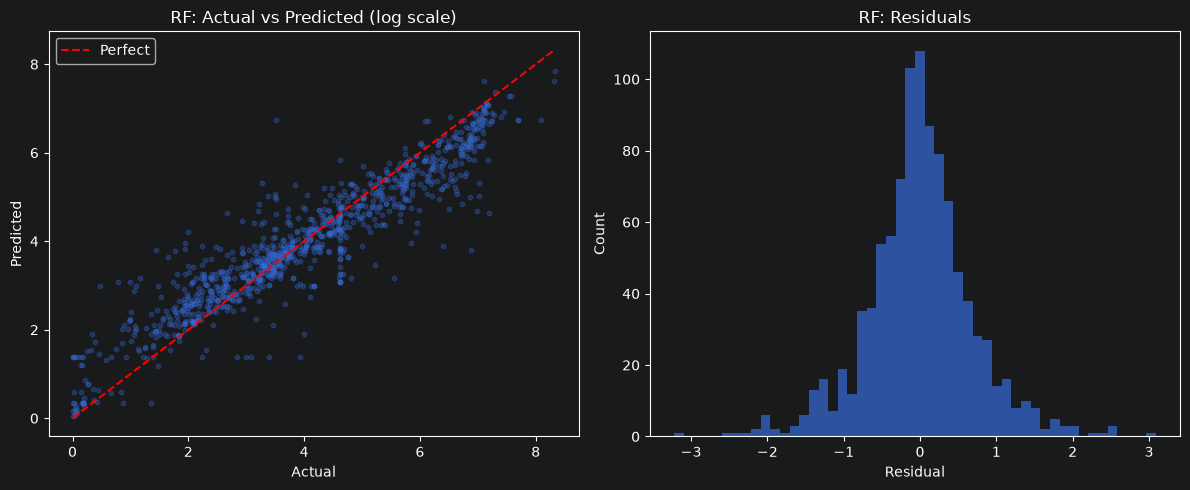

In [8]:
# Визуализация: лучшая модель vs predicted
best_model_name = best
best_models_dict = {
    'DummyMean': DummyRegressor(strategy='mean'),
    'DummyMedian': DummyRegressor(strategy='median'),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.01, max_iter=5000),
    'KNN': KNeighborsRegressor(n_neighbors=5),
    'RF': RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE),
    'HGB': HistGradientBoostingRegressor(max_iter=200, max_depth=6, random_state=RANDOM_STATE)
}

m = best_models_dict[best_model_name]
m.fit(Xs, y_use)
preds = m.predict(Xs)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(y_use, preds, alpha=0.3, s=10)
mn, mx = min(y_use.min(), preds.min()), max(y_use.max(), preds.max())
axes[0].plot([mn, mx], [mn, mx], 'r--', label='Perfect')
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')
axes[0].set_title(f'{best_model_name}: Actual vs Predicted (log scale)')
axes[0].legend()

axes[1].hist(y_use - preds, bins=50, alpha=0.7)
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Count')
axes[1].set_title(f'{best_model_name}: Residuals')

plt.tight_layout()
plt.savefig(f'{ASSETS_DIR}/reg_ic50_actual_vs_pred.png', dpi=150, bbox_inches='tight')
plt.show()


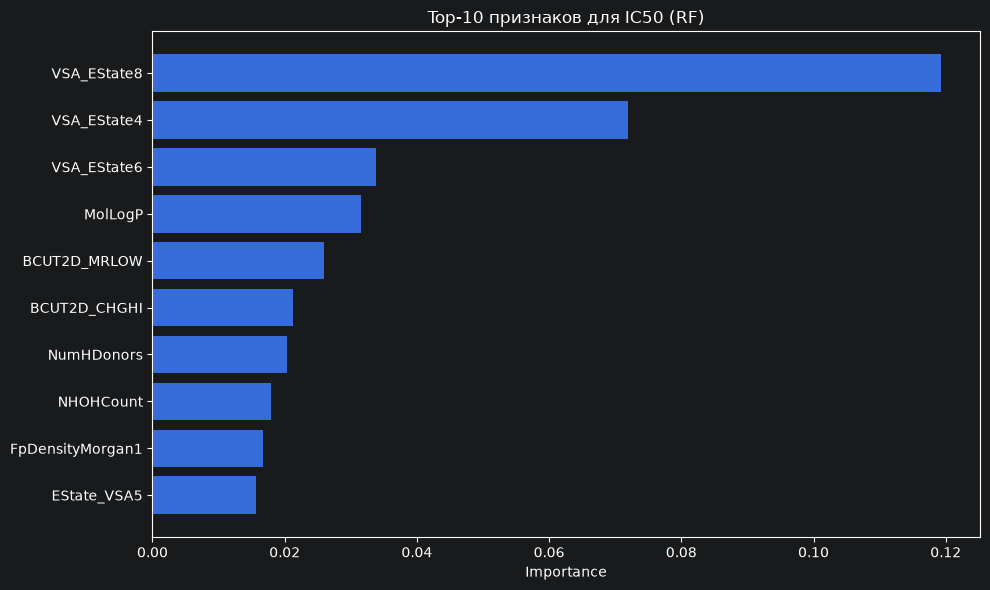

In [9]:
# Feature importance для лучшей модели
from sklearn.ensemble import RandomForestRegressor as RFReg

rf = RFReg(n_estimators=100, random_state=RANDOM_STATE)
rf.fit(Xs, y_use)
imp = rf.feature_importances_
top_idx = np.argsort(imp)[-10:][::-1]

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
names = [feat_cols[i] for i in top_idx]
values = [imp[i] for i in top_idx]
ax.barh(range(len(names)), values[::-1])
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names[::-1])
ax.set_xlabel('Importance')
ax.set_title('Top-10 признаков для IC50 (RF)')

plt.tight_layout()
plt.savefig(f'{ASSETS_DIR}/reg_ic50_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
